<a href="https://colab.research.google.com/github/SKSAHILAKHTAR1/AI-Powered-SDR-Laboratory/blob/main/Digital_Communication/Experiment_3_Sampling_Theorem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

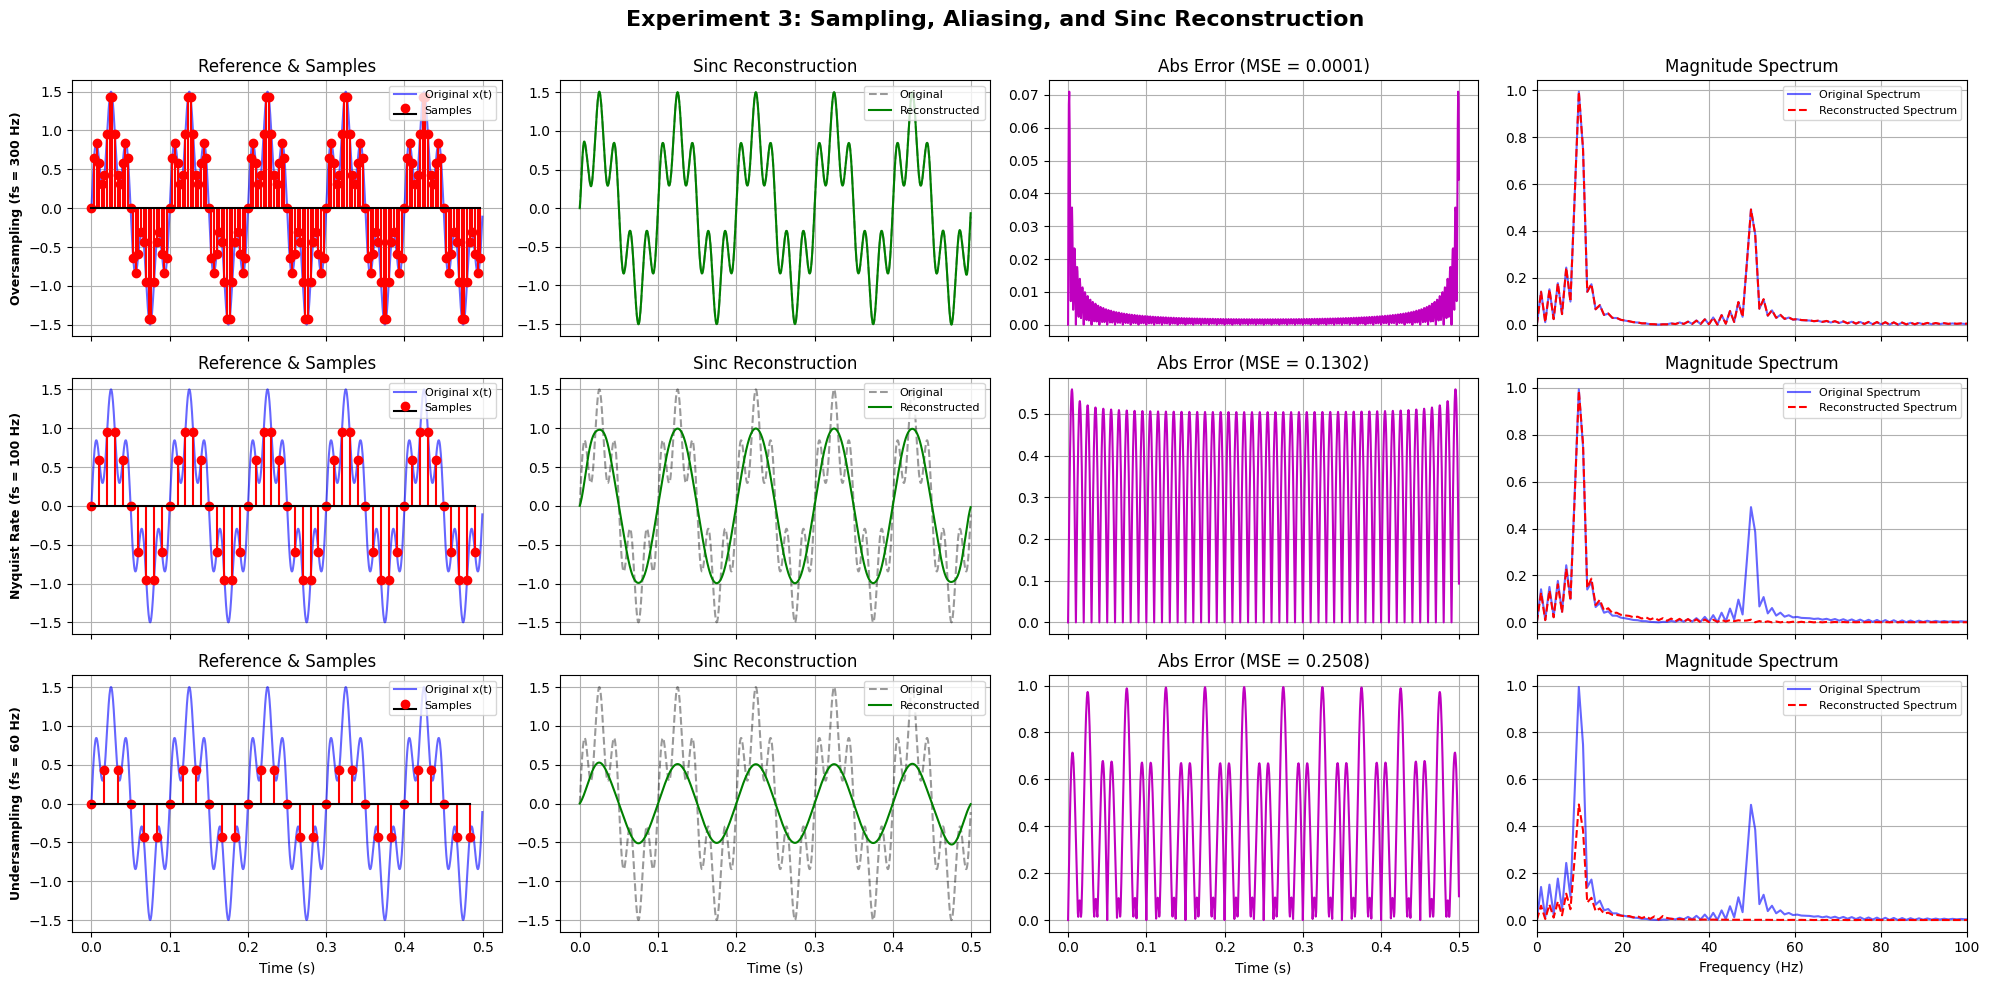

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PARAMETERS & CONTINUOUS REFERENCE SIGNAL
# ==========================================
f1, f2 = 10, 50                  # Signal frequencies (Hz)
f_max = max(f1, f2)              # Maximum frequency = 50 Hz
nyquist_rate = 2 * f_max         # Nyquist rate = 100 Hz

# High resolution time grid to simulate continuous physical signal
f_analog = 2000                  # Plotting resolution (Hz)
t_duration = 0.5                 # Duration in seconds
t_fine = np.linspace(0, t_duration, int(f_analog * t_duration), endpoint=False)

# Continuous Reference Signal x(t)
x_fine = np.sin(2 * np.pi * f1 * t_fine) + 0.5 * np.sin(2 * np.pi * f2 * t_fine)

# Sampling rates to evaluate
sampling_rates = {
    'Oversampling (fs = 300 Hz)': 300,
    'Nyquist Rate (fs = 100 Hz)': 100,
    'Undersampling (fs = 60 Hz)': 60
}

# ==========================================
# 2. SINC INTERPOLATION FUNCTION
# ==========================================
def sinc_reconstruction(t_samples, x_samples, t_fine, fs):
    """
    Reconstructs the continuous signal from discrete samples using sinc interpolation.
    x_r(t) = sum( x[n] * sinc( (t - n*Ts) / Ts ) )
    """
    Ts = 1.0 / fs
    # Compute sinc matrix: rows correspond to fine time points, cols to sample points
    sinc_matrix = np.sinc((t_fine[:, None] - t_samples[None, :]) / Ts)
    return np.dot(sinc_matrix, x_samples)

# ==========================================
# 3. SIMULATION & PLOTTING
# ==========================================
fig, axes = plt.subplots(len(sampling_rates), 4, figsize=(20, 10), sharex='col')
fig.suptitle("Experiment 3: Sampling, Aliasing, and Sinc Reconstruction", fontsize=16, fontweight='bold')

for idx, (title, fs) in enumerate(sampling_rates.items()):
    # Discrete Sampling
    Ts = 1.0 / fs
    t_samples = np.arange(0, t_duration, Ts)
    x_samples = np.sin(2 * np.pi * f1 * t_samples) + 0.5 * np.sin(2 * np.pi * f2 * t_samples)

    # Sinc Interpolation Reconstruction
    x_reconstructed = sinc_reconstruction(t_samples, x_samples, t_fine, fs)

    # Reconstruction Error
    error = np.abs(x_fine - x_reconstructed)
    mse = np.mean((x_fine - x_reconstructed) ** 2)

    # Magnitude Spectra Calculation (FFT)
    N_fft = 2048
    freqs = np.fft.rfftfreq(N_fft, d=1/f_analog)
    X_orig_mag = np.abs(np.fft.rfft(x_fine, n=N_fft)) / (len(x_fine) / 2)
    X_recon_mag = np.abs(np.fft.rfft(x_reconstructed, n=N_fft)) / (len(x_fine) / 2)

    # --- Column 1: Reference vs Sampled Signal ---
    axes[idx, 0].plot(t_fine, x_fine, 'b-', label='Original x(t)', alpha=0.6)
    axes[idx, 0].stem(t_samples, x_samples, 'r', linefmt='r-', markerfmt='ro', basefmt='k-', label='Samples')
    axes[idx, 0].set_ylabel(title, fontweight='bold', fontsize=9)
    axes[idx, 0].set_title("Reference & Samples")
    axes[idx, 0].grid(True)
    axes[idx, 0].legend(loc='upper right', fontsize=8)

    # --- Column 2: Reconstructed Signal ---
    axes[idx, 1].plot(t_fine, x_fine, 'k--', label='Original', alpha=0.4)
    axes[idx, 1].plot(t_fine, x_reconstructed, 'g-', label='Reconstructed')
    axes[idx, 1].set_title("Sinc Reconstruction")
    axes[idx, 1].grid(True)
    axes[idx, 1].legend(loc='upper right', fontsize=8)

    # --- Column 3: Reconstruction Error ---
    axes[idx, 2].plot(t_fine, error, 'm-')
    axes[idx, 2].set_title(f"Abs Error (MSE = {mse:.4f})")
    axes[idx, 2].grid(True)

    # --- Column 4: Magnitude Spectrum Comparison ---
    axes[idx, 3].plot(freqs, X_orig_mag, 'b-', label='Original Spectrum', alpha=0.6)
    axes[idx, 3].plot(freqs, X_recon_mag, 'r--', label='Reconstructed Spectrum')
    axes[idx, 3].set_xlim(0, 100)
    axes[idx, 3].set_title("Magnitude Spectrum")
    axes[idx, 3].grid(True)
    axes[idx, 3].legend(loc='upper right', fontsize=8)

# Set x-labels for bottom plots
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
axes[-1, 2].set_xlabel("Time (s)")
axes[-1, 3].set_xlabel("Frequency (Hz)")

plt.tight_layout()
plt.subplots_adjust(top=0.91)
plt.show()